# 라이브러리 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

# 데이터 평균 표준편차 구하기

In [2]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FlatImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        self.files = [f for f in os.listdir(root) if f.lower().endswith(exts)]
        if len(self.files) == 0:
            raise FileNotFoundError(f"No images found in: {root}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root, self.files[idx])
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

root = r"C:\project\TEAM-PJ-DEEP\복만수\data\train"
dataset = FlatImageDataset(root, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

# ✅ 전체 픽셀 기준 누적합/제곱합
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images in loader:  # images: (B,3,224,224)
    b, c, h, w = images.shape
    num_pixels += b * h * w
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])

mean = channel_sum / num_pixels
var = (channel_sq_sum / num_pixels) - (mean ** 2)
std = torch.sqrt(var)

print("mean:", mean)
print("std:", std)

mean: tensor([0.9313, 0.9314, 0.9307])
std: tensor([0.1014, 0.1016, 0.1015])


# 정규화

In [3]:
from torchvision import transforms

MEAN = [0.9313, 0.9314, 0.9307]
STD  = [0.1014, 0.1016, 0.1015]

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# 데이터 불러오기
## 이미지와 라벨(csv)을 함께 읽어서 학습용 데이터셋으로 만드는 코드

In [4]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os

class MultiLabelDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.labels = self.data.iloc[:, 1:].values

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

# 데이터를 학습용/검증용/테스트용 Dataset 객체 생성

In [5]:
num_classes = 14

train_dataset = MultiLabelDataset(
    csv_file="./data/train_labels.csv",
    img_dir="./data/train",
    transform=transform_train
)

val_dataset = MultiLabelDataset(
    csv_file="./data/val_labels.csv",
    img_dir="./data/val",
    transform=transform_val
)

test_dataset = MultiLabelDataset(
    csv_file="./data/test_labels.csv",
    img_dir="./data/test",
    transform=transform_test
)

# DataLoader 생성
## Dataset을 실제 학습에 사용할 수 있게 배치 단위로 묶는 단계

In [6]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=0)

# 클래스 분균형 보정 pos_weight 계산 단계

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv("./data/train_labels.csv")
labels = df.iloc[:, 1:].values.astype(np.float32)

pos_counts = labels.sum(axis=0)
neg_counts = labels.shape[0] - pos_counts

# 0 방지
pos_counts = np.clip(pos_counts, 1.0, None)

pos_weight = neg_counts / pos_counts
pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)
# pow_weight는 양성 클래스(값이 1인 경우)에 더 큰 중요도를 주는 가중치
# 1 = 해당 항목이 작성됨 0 = 해당 항목이 비어있음 일 때
# 실제 데이터는 많은 경우 0이 훨씬 만다 
# 이럴 때 모델이 대충 다 0이라고만 예측해도 손실이 크게 안나서 1을 잘 못잡는 문제가 생긴다
# pow_weight를 써서 1을 틀렸을 떄는 더 크게 벌주고, 0을 틀렸을 때보다 더 중요하게 보게 만드는 것

# 모델 불러오기

In [8]:
model = models.resnet50(pretrained=True)

# 전체 freeze
for p in model.parameters():
    p.requires_grad = False

# fc 라는 층을 새로 만드는것
model.fc = nn.Linear(model.fc.in_features, num_classes)

# fc만 확실히 학습
for p in model.fc.parameters():
    p.requires_grad = True

model = model.to(device)

c:\project\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\project\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# 모델 확인

In [9]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# 지금 어떤게 안얼었는지 얼었는지 확인

In [10]:
# 지금 어떤게 안얼었는지 얼었는지 확인
for name,module in model.named_parameters():
    print(name , module.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.0.conv3.weight False
layer1.0.bn3.weight False
layer1.0.bn3.bias False
layer1.0.downsample.0.weight False
layer1.0.downsample.1.weight False
layer1.0.downsample.1.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.1.conv3.weight False
layer1.1.bn3.weight False
layer1.1.bn3.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer1.2.conv3.weight False
layer1.2.bn3.weight False
layer1.2.bn3.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2

# 학습하기

In [11]:
import tqdm
from torch.utils.tensorboard import SummaryWriter
import os
import torch

os.makedirs("checkpoints", exist_ok=True)
writer = SummaryWriter()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)  # ✅ 핵심: 모델도 GPU로

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # pos_weight도 device에 있어야 함(너는 올려놨다고 했지)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 50
best_val_loss = float("inf")
stop_count = 5
early_stop_count = 0
tensorboard_count = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    batch_count = 0

    # ✅ train_loader로 돌려야 정상 (batch 학습)
    for img, labels in tqdm.tqdm(train_loader):
        img = img.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        preds = model(img)
        loss = criterion(preds, labels)

        writer.add_scalar("Loss/train", loss.item(), tensorboard_count)
        tensorboard_count += 1

        running_loss += loss.item()
        batch_count += 1

        loss.backward()
        optimizer.step()

    avg_train_loss = running_loss / max(batch_count, 1)

    # ===== Validation =====
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for img, labels in val_loader:   # ✅ val_loader
            img = img.to(device)
            labels = labels.to(device)
            pred = model(img)
            val_loss_sum += criterion(pred, labels).item()

    total_val_loss = val_loss_sum / len(val_loader)

    # Early stopping + best 저장
    if total_val_loss < best_val_loss:
        early_stop_count = 0
        best_val_loss = total_val_loss
        torch.save(model.state_dict(), "checkpoints/best_model_resnet50.pth")  # ✅ save
    else:
        early_stop_count += 1
        if early_stop_count >= stop_count:
            print("🛑 Early stopping")
            break

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {total_val_loss:.4f}, Best Val Loss: {best_val_loss:.4f}, EarlyStopCount: {early_stop_count}")

writer.close()

100%|██████████| 88/88 [00:08<00:00, 10.65it/s]


Epoch 1, Train Loss: 0.5453, Val Loss: 0.4639, Best Val Loss: 0.4639, EarlyStopCount: 0


100%|██████████| 88/88 [00:07<00:00, 11.40it/s]


Epoch 2, Train Loss: 0.4382, Val Loss: 0.3684, Best Val Loss: 0.3684, EarlyStopCount: 0


100%|██████████| 88/88 [00:08<00:00,  9.98it/s]


...

Epoch 48, Train Loss: 0.0837, Val Loss: 0.0530, Best Val Loss: 0.0520, EarlyStopCount: 2


100%|██████████| 88/88 [00:07<00:00, 11.31it/s]


Epoch 49, Train Loss: 0.0759, Val Loss: 0.0482, Best Val Loss: 0.0482, EarlyStopCount: 0


100%|██████████| 88/88 [00:07<00:00, 11.27it/s]


Epoch 50, Train Loss: 0.0744, Val Loss: 0.0519, Best Val Loss: 0.0482, EarlyStopCount: 1


# test 폴더 전체 확인 값

In [72]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5

model = model.to(device)
model.eval()

total_labels = 0
correct_labels = 0

total_samples = 0
correct_samples = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).float()      # (B,14)

        logits = model(imgs)                    # (B,14)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()       # (B,14)

        # label accuracy
        correct_labels += (preds == labels.int()).sum().item()
        total_labels += labels.numel()

        # subset accuracy (14개 전부 맞아야 정답)
        correct_samples += (preds == labels.int()).all(dim=1).sum().item()
        total_samples += labels.size(0)

label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

print(f"label_acc:  {label_acc*100:.2f}%")
print(f"subset_acc: {subset_acc*100:.2f}%  (14개 전부 맞춘 비율)")

label_acc:  97.49%
subset_acc: 86.75%  (14개 전부 맞춘 비율)


In [13]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# 기존 accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# ✅ micro용 TP/FP/FN 누적
tp_micro = 0
fp_micro = 0
fn_micro = 0

# ✅ macro용: 라벨별 TP/FP/FN 누적 (14개)
num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()  # (B,14) 0/1

        logits = model(imgs)                  # (B,14)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()     # (B,14)

        # ===== 기존: label_acc / subset_acc =====
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # ===== ✅ micro TP/FP/FN =====
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # ===== ✅ macro(라벨별) TP/FP/FN =====
        # sum over batch dimension
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# ===== accuracy =====
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# ===== ✅ micro precision/recall/f1 =====
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro    = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro        = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# ===== ✅ macro precision/recall/f1 (라벨별 계산 후 평균) =====
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class    = tp_c / (tp_c + fn_c + EPS)
f1_per_class        = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + EPS)

precision_macro = precision_per_class.mean().item()
recall_macro    = recall_per_class.mean().item()
f1_macro        = f1_per_class.mean().item()

print(f"label_acc:       {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)")
print(f"subset_acc:      {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")

print(f"precision_micro: {precision_micro*100:.2f}% 모델이 “1(작성됨)”이라고 예측한 것들 중 실제로도 1인 비율")
print(f"recall_micro:    {recall_micro*100:.2f}% 실제로 “1(작성됨)”인 것들 중 모델이 1이라고 찾아낸 비율")
print(f"f1_micro:        {f1_micro*100:.2f}% “작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표")

print(f"precision_macro: {precision_macro*100:.2f}% 라벨(항목)별로 precision을 각각 구하고 그걸 14개 평균낸 값")
print(f"recall_macro:    {recall_macro*100:.2f}% “항목별로 봐도, 전반적으로 1을 잘 찾아낸다”")
print(f"f1_macro:        {f1_macro*100:.2f}% 라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호")

label_acc:       97.40% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc:      86.75% (14개 전부 맞춘 비율)
precision_micro: 99.20% 모델이 “1(작성됨)”이라고 예측한 것들 중 실제로도 1인 비율
recall_micro:    96.07% 실제로 “1(작성됨)”인 것들 중 모델이 1이라고 찾아낸 비율
f1_micro:        97.61% “작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표
precision_macro: 99.01% 라벨(항목)별로 precision을 각각 구하고 그걸 14개 평균낸 값
recall_macro:    97.28% “항목별로 봐도, 전반적으로 1을 잘 찾아낸다”
f1_macro:        98.10% 라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호


In [14]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

model = model.to(device)
model.eval()

# accuracy용
total_labels = 0
correct_labels = 0
total_samples = 0
correct_samples = 0

# F1용
tp_micro = 0
fp_micro = 0
fn_micro = 0

num_classes = 14
tp_c = torch.zeros(num_classes, dtype=torch.float64)
fp_c = torch.zeros(num_classes, dtype=torch.float64)
fn_c = torch.zeros(num_classes, dtype=torch.float64)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device).int()

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).int()

        # acc
        correct_labels += (preds == labels).sum().item()
        total_labels += labels.numel()

        correct_samples += (preds == labels).all(dim=1).sum().item()
        total_samples += labels.size(0)

        # micro F1
        tp_micro += ((preds == 1) & (labels == 1)).sum().item()
        fp_micro += ((preds == 1) & (labels == 0)).sum().item()
        fn_micro += ((preds == 0) & (labels == 1)).sum().item()

        # macro F1
        tp_c += ((preds == 1) & (labels == 1)).sum(dim=0).cpu().double()
        fp_c += ((preds == 1) & (labels == 0)).sum(dim=0).cpu().double()
        fn_c += ((preds == 0) & (labels == 1)).sum(dim=0).cpu().double()

# accuracy
label_acc = correct_labels / total_labels
subset_acc = correct_samples / total_samples

# micro F1
precision_micro = tp_micro / (tp_micro + fp_micro + EPS)
recall_micro = tp_micro / (tp_micro + fn_micro + EPS)
f1_micro = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# macro F1
precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class = tp_c / (tp_c + fn_c + EPS)
f1_per_class = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + EPS)
f1_macro = f1_per_class.mean().item()

print(f"label_acc:  {label_acc*100:.2f}% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)")
print(f"subset_acc: {subset_acc*100:.2f}% (14개 전부 맞춘 비율)")
print(f"f1_micro:   {f1_micro*100:.2f}% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)")
print(f"f1_macro:   {f1_macro*100:.2f}% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)")

label_acc:  97.40% (모든 테스트 이미지의 모든 라벨을 다 펼처서 정확도 확인)
subset_acc: 86.75% (14개 전부 맞춘 비율)
f1_micro:   97.61% (작성됨(1)에 대해 잘못 예측한 경우(FP)와 놓친 경우(FN)를 함께 고려한 전체 성능 지표)
f1_macro:   98.10% (라벨별 F1을 구해 평균 14개 항목을 비슷하게 잘 맞추고 있다는 신호)


# 딱 1장에 대해서 test

In [12]:
import os
import pandas as pd
import torch
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5

img_name = "학습-전입신고서436.jpg"
img_path = os.path.join("./data/test", img_name)

# 1) 이미지
image = Image.open(img_path).convert("RGB")
x = transform_test(image).unsqueeze(0).to(device)

# 2) 정답 라벨 찾기
df = pd.read_csv("./data/test_labels.csv")

row = df[df.iloc[:, 0].astype(str).str.strip() == img_name]
if len(row) == 0:
    raise ValueError(f"{img_name} not found in test_labels.csv")

# ✅ 라벨을 숫자로 강제 변환 (문자/빈칸은 0으로 처리)
label_series = row.iloc[0, 1:]
label_numeric = pd.to_numeric(label_series, errors="coerce").fillna(0).astype(np.int64)

y = torch.tensor(label_numeric.values, dtype=torch.int64, device=device)  # (14,)

# 3) 추론
model = model.to(device)
model.eval()
with torch.no_grad():
    logits = model(x)                         # (1,14)
    probs = torch.sigmoid(logits).squeeze(0)  # (14,)
    pred = (probs > THRESHOLD).int()          # (14,)

# 4) 1장 label_acc / subset_acc
correct_labels = (pred == y).sum().item()
total_labels = y.numel()
label_acc = correct_labels / total_labels
subset_acc = 1.0 if (pred == y).all().item() else 0.0

print("GT  :", y.cpu().tolist(), "test_labels.csv에서 가져온 값")
print("PRED:", pred.cpu().tolist(), "모델이 예측한 값")
print("PROB:", [round(v, 3) for v in probs.cpu().tolist()])
print(f"label_acc:  {label_acc*100:.2f}%")
print(f"subset_acc: {subset_acc*100:.2f}%  (14개 전부 맞춘 비율)")

GT  : [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1] test_labels.csv에서 가져온 값
PRED: [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1] 모델이 예측한 값
PROB: [0.036, 0.041, 0.988, 0.976, 0.986, 0.98, 0.993, 0.997, 0.993, 0.033, 0.979, 0.904, 0.888, 0.883]
label_acc:  100.00%
subset_acc: 100.00%  (14개 전부 맞춘 비율)


In [24]:
import os
import pandas as pd
import torch
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5
EPS = 1e-12

img_name = "학습-전입신고서436.jpg"
img_path = os.path.join("./data/test", img_name)

# 1) 이미지
image = Image.open(img_path).convert("RGB")
x = transform_test(image).unsqueeze(0).to(device)

# 2) 정답 라벨
df = pd.read_csv("./data/test_labels.csv")
row = df[df.iloc[:, 0].astype(str).str.strip() == img_name]
if len(row) == 0:
    raise ValueError(f"{img_name} not found in test_labels.csv")

label_series = row.iloc[0, 1:]
label_numeric = pd.to_numeric(label_series, errors="coerce").fillna(0).astype(np.int64)
y = torch.tensor(label_numeric.values, dtype=torch.int64, device=device)  # (14,)

# 3) 추론
model = model.to(device)
model.eval()
with torch.no_grad():
    logits = model(x)                         # (1,14)
    probs = torch.sigmoid(logits).squeeze(0)  # (14,)
    pred = (probs > THRESHOLD).int()          # (14,)

# ===== 4) 1장 accuracy =====
correct_labels = (pred == y).sum().item()
total_labels = y.numel()
label_acc = correct_labels / total_labels
subset_acc = 1.0 if (pred == y).all().item() else 0.0

# ===== 5) 1장 micro precision/recall/f1 =====
tp = ((pred == 1) & (y == 1)).sum().item()
fp = ((pred == 1) & (y == 0)).sum().item()
fn = ((pred == 0) & (y == 1)).sum().item()

precision_micro = tp / (tp + fp + EPS)
recall_micro    = tp / (tp + fn + EPS)
f1_micro        = 2 * precision_micro * recall_micro / (precision_micro + recall_micro + EPS)

# ===== 6) 1장 macro precision/recall/f1 (라벨별 계산 후 평균) =====
tp_c = ((pred == 1) & (y == 1)).double()
fp_c = ((pred == 1) & (y == 0)).double()
fn_c = ((pred == 0) & (y == 1)).double()

precision_per_class = tp_c / (tp_c + fp_c + EPS)
recall_per_class    = tp_c / (tp_c + fn_c + EPS)
f1_per_class        = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + EPS)

precision_macro = precision_per_class.mean().item()
recall_macro    = recall_per_class.mean().item()
f1_macro        = f1_per_class.mean().item()

# ===== 출력 =====
print("GT  :", y.cpu().tolist(), " (test_labels.csv에서 가져온 정답)")
print("PRED:", pred.cpu().tolist(), " (모델 예측 0/1)")
print("PROB:", [round(v, 3) for v in probs.cpu().tolist()], " (채워짐 확률)")

print(f"label_acc:       {label_acc*100:.2f}%")
print(f"subset_acc:      {subset_acc*100:.2f}%  (14개 전부 맞춘 비율)")

print(f"precision_micro: {precision_micro*100:.2f}%")
print(f"recall_micro:    {recall_micro*100:.2f}%")
print(f"f1_micro:        {f1_micro*100:.2f}%")

print(f"precision_macro: {precision_macro*100:.2f}%")
print(f"recall_macro:    {recall_macro*100:.2f}%")
print(f"f1_macro:        {f1_macro*100:.2f}%")

GT  : [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]  (test_labels.csv에서 가져온 정답)
PRED: [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]  (모델 예측 0/1)
PROB: [0.019, 0.03, 0.913, 0.88, 0.928, 0.938, 0.974, 0.986, 0.978, 0.097, 0.974, 0.854, 0.855, 0.871]  (채워짐 확률)
label_acc:       100.00%
subset_acc:      100.00%  (14개 전부 맞춘 비율)
precision_micro: 100.00%
recall_micro:    100.00%
f1_micro:        100.00%
precision_macro: 78.57%
recall_macro:    78.57%
f1_macro:        78.57%


# Grad-CAM

# 라이브러리 불러오기

In [75]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 모델 불러오기

In [76]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load('./checkpoints/best_model_resnet50.pth',map_location='cpu')) # map_location='cpu' 는 cpu 환경에서 불러와라

c:\project\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\project\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

# GPU(CPU) 사용 가능 여부 확인

In [77]:
import torch
print(torch.cuda.is_available())

True


# 추론

In [99]:
from PIL import Image
import torch

model.eval()
model.to('cuda')

img = Image.open('data/test/학습-전입신고서436.jpg').convert('RGB')
input_tensor = transform_test(img).unsqueeze(0).to('cuda')

with torch.no_grad():
    pred = model(input_tensor)          # logits
    probs = torch.sigmoid(pred)         # 각 라벨 확률
    preds = (probs > 0.5).int()         # threshold 0.5 기준 0/1

print("logits:", pred)
print("probs:", probs)
print("preds:", preds)

logits: tensor([[-3.9967, -2.9050,  4.5564,  4.2525,  3.7303,  2.8388,  4.0122,  4.7858,
          3.8829, -3.3104,  3.0603,  2.5164,  2.5713,  2.5683]],
       device='cuda:0')
probs: tensor([[0.0180, 0.0519, 0.9896, 0.9860, 0.9766, 0.9447, 0.9822, 0.9917, 0.9798,
         0.0352, 0.9552, 0.9253, 0.9290, 0.9288]], device='cuda:0')
preds: tensor([[0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1]], device='cuda:0',
       dtype=torch.int32)


# 타겟 레이어

In [79]:
target_layers = [model.layer4[-1]]
# 마지막 레이어를 가져오는게 좋은데 모르겠으면 지피티한테 물어보기 
# 마지막 에이어가 몇번이야?

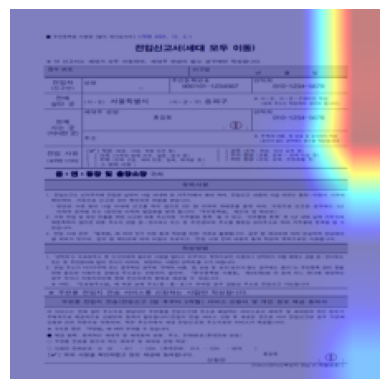

In [100]:
import matplotlib.pyplot as plt

target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)
target_label = 1   # 보고 싶은 라벨 번호
grad_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_label)])[0]

rgb_img = np.array(img.resize((224,224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")
plt.show()